# Step 4 — Face normalization

Normalization is a preprocessing step that makes faces easier for machine-learning algorithms to
compare. The goal is the **best representation for an algorithm, not for the human eye** — some
normalized faces will barely look like faces, and that's expected.

This notebook runs the full pipeline end-to-end — **loop through videos and frames → detect face &
landmarks → crop & align → normalize** — and implements three normalizations:

1. **Global mean/std** — subtract the mean face of the whole database and divide by its std (per pixel).
2. **Histogram normalization (CLAHE)** — per image, applied separately to each colour channel.
3. **Contrast/brightness (MIN-MAX)** — stretch each face's values to the full 0–255 range.

## Imports, detector, and the Step 2–3 pipeline

(`KMP_DUPLICATE_LIB_OK` set before importing torch/OpenCV — see Step 2.)

In [1]:
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")
os.environ.setdefault("OMP_NUM_THREADS", "1")

import cv2
import glob
import numpy as np
from math import atan2, degrees, hypot
from pathlib import Path
import matplotlib.pyplot as plt
from facenet_pytorch import MTCNN

root = Path.cwd()
while not (root / "Data").exists() and root != root.parent:
    root = root.parent
REAL_DIR = root / "Data" / "VidTIMIT"
FAKE_DIR = root / "Data" / "DeepfakeTIMIT" / "higher_quality"

detector = MTCNN(keep_all=True, device="cpu")

DESIRED_SIZE     = (256, 256)
DESIRED_LEFT_EYE = (0.35, 0.35)

def detect_faces(image_rgb):
    boxes, probs, landmarks = detector.detect(image_rgb, landmarks=True)
    faces = []
    if boxes is None:
        return faces
    for box, prob, lm in zip(boxes, probs, landmarks):
        x1, y1, x2, y2 = (float(v) for v in box)
        faces.append({"box": (x1, y1, x2 - x1, y2 - y1),
                      "left_eye": tuple(float(v) for v in lm[0]),
                      "right_eye": tuple(float(v) for v in lm[1]),
                      "confidence": float(prob)})
    return faces

def eyes_angle(left_eye, right_eye):
    return degrees(atan2(right_eye[1] - left_eye[1], right_eye[0] - left_eye[0]))

def scaling_factor(current_eye_dist, desired_eye_dist_ratio, desired_width):
    return (desired_eye_dist_ratio * desired_width) / current_eye_dist

def crop_and_align(desired_size, desired_left_eye, image, eyes):
    left_eye, right_eye = eyes
    des_w, des_h = desired_size
    angle = eyes_angle(left_eye, right_eye)
    current_dist = hypot(right_eye[0] - left_eye[0], right_eye[1] - left_eye[1])
    scale = scaling_factor(current_dist, 1.0 - 2.0 * desired_left_eye[0], des_w)
    center = ((left_eye[0] + right_eye[0]) / 2.0, (left_eye[1] + right_eye[1]) / 2.0)
    M = cv2.getRotationMatrix2D(center, angle, scale)
    M[0, 2] += des_w * 0.5 - center[0]
    M[1, 2] += des_h * desired_left_eye[1] - center[1]
    return cv2.warpAffine(image, M, (des_w, des_h), flags=cv2.INTER_CUBIC)

print("Pipeline ready. Root:", root)

/Users/blake/opt/anaconda3/envs/deepfake-detect/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Pipeline ready. Root: /Users/blake/AI Projects/Deepfake-Detection


## Build the aligned-face database — loop through videos and frames

We loop over several real and fake videos, and for every sampled frame we detect the face, align it,
and save it. Frames are subsampled (`FRAME_STEP`) to keep this fast while still producing a
representative database. These aligned faces are the input to the normalizations below.

In [2]:
SUBJECTS   = ["fadg0", "faks0", "fcft0"]
UTTERANCE  = "sa1"
FRAME_STEP = 6      # process every 6th frame

# Real clips are <utterance>.avi; fake clips are <utterance>-video-<source>.avi
# where <source> varies per subject, so we discover the fake file with a glob.
videos = []
for s in SUBJECTS:
    real = REAL_DIR / s / f"{UTTERANCE}.avi"
    if real.exists():
        videos.append((real, "real", s))
    fakes = sorted(glob.glob(str(FAKE_DIR / s / f"{UTTERANCE}-video-*.avi")))
    if fakes:
        videos.append((Path(fakes[0]), "fake", s))

aligned_root = root / "Data" / "faces_aligned"

def build_aligned(video_path, label, subject):
    out_dir = aligned_root / f"{subject}_{UTTERANCE}_{label}"
    out_dir.mkdir(parents=True, exist_ok=True)
    cap = cv2.VideoCapture(str(video_path))
    saved, idx = 0, 0
    while True:
        ok, frame_bgr = cap.read()
        if not ok:
            break
        if idx % FRAME_STEP == 0:
            image_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
            for j, f in enumerate(detect_faces(image_rgb)):
                aligned = crop_and_align(DESIRED_SIZE, DESIRED_LEFT_EYE,
                                         image_rgb, (f["left_eye"], f["right_eye"]))
                cv2.imwrite(str(out_dir / f"frame{idx:04d}_face{j}.jpg"),
                            cv2.cvtColor(aligned, cv2.COLOR_RGB2BGR))
                saved += 1
        idx += 1
    cap.release()
    return saved

total = 0
for path, label, subject in videos:
    n = build_aligned(path, label, subject)
    total += n
    print(f"{label:4s} {subject}: {n} aligned faces")
print("Total aligned faces:", total)

[W NNPACK.cpp:64] Could not initialize NNPACK! Reason: Unsupported hardware.


real fadg0: 20 aligned faces
fake fadg0: 20 aligned faces
real faks0: 15 aligned faces
fake faks0: 15 aligned faces
real fcft0: 17 aligned faces
fake fcft0: 17 aligned faces
Total aligned faces: 104


## Read all aligned faces into one large NumPy array

In [3]:
face_files = sorted(glob.glob(str(aligned_root / "**" / "*.jpg"), recursive=True))
faces = np.stack([cv2.cvtColor(cv2.imread(f), cv2.COLOR_BGR2RGB) for f in face_files]).astype(np.float32)
print("Loaded", faces.shape[0], "faces into array of shape", faces.shape, faces.dtype)

# a helper to rescale any array to [0,1] purely for *display*
def to_display(x):
    x = x.astype(np.float32)
    lo, hi = x.min(), x.max()
    return (x - lo) / (hi - lo + 1e-8)

sample = faces[0].astype(np.uint8)   # a reference face used in the plots below

Loaded 203 faces into array of shape (203, 256, 256, 3) float32


## 1. Global normalization — subtract the mean, divide by the std

Computed **across the whole database**: `mean_img` and `std_img` are per-pixel, per-channel statistics.
For every face, `(face - mean_img) / std_img` is the normalized result.

Because we subtract the *mean face*, the normalized face no longer looks like a face — that's the point.
It highlights how each face **deviates** from the average, which is what many algorithms care about.

normalized value range: -12.64 .. 13.64  (mean -0.000, std 1.000)


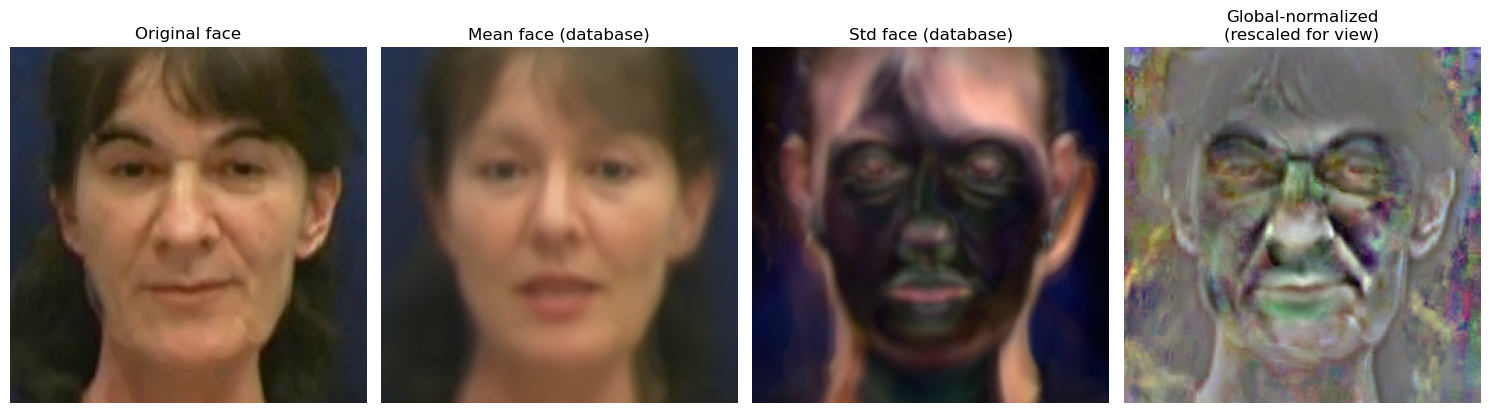

In [4]:
mean_img = faces.mean(axis=0)                 # (256,256,3) mean face
std_img  = faces.std(axis=0)                  # (256,256,3) std face
global_norm = (faces - mean_img) / (std_img + 1e-7)

print("normalized value range: %.2f .. %.2f  (mean %.3f, std %.3f)"
      % (global_norm.min(), global_norm.max(), global_norm.mean(), global_norm.std()))

fig, ax = plt.subplots(1, 4, figsize=(15, 4))
ax[0].imshow(sample);                          ax[0].set_title("Original face")
ax[1].imshow(mean_img.astype(np.uint8));       ax[1].set_title("Mean face (database)")
ax[2].imshow(to_display(std_img));             ax[2].set_title("Std face (database)")
ax[3].imshow(to_display(global_norm[0]));      ax[3].set_title("Global-normalized\n(rescaled for view)")
for a in ax: a.axis("off")
plt.tight_layout(); plt.show()

## 2. Histogram normalization — CLAHE, per colour channel

**CLAHE** (Contrast Limited Adaptive Histogram Equalization) equalizes the histogram in local tiles,
boosting local contrast without over-amplifying noise. The assignment asks for it **separately on each
colour channel**, so we apply the same CLAHE to R, G and B and merge.

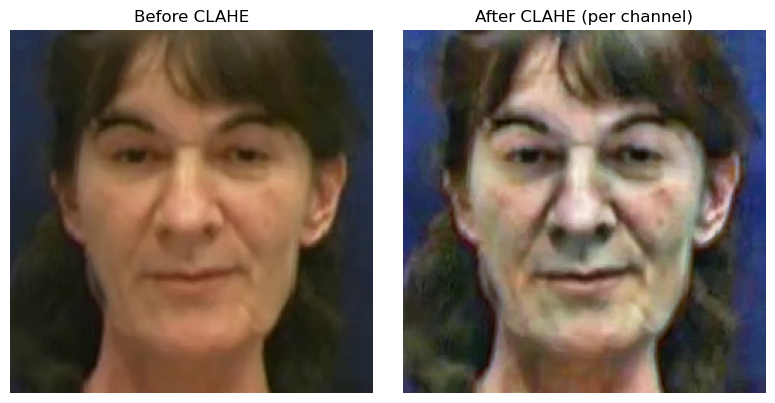

In [5]:
def clahe_normalize(face_uint8, clip_limit=2.0, tile=(8, 8)):
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile)
    channels = [clahe.apply(face_uint8[:, :, c]) for c in range(3)]   # per-channel
    return np.stack(channels, axis=2)

clahe_face = clahe_normalize(sample)

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(sample);      ax[0].set_title("Before CLAHE");            ax[0].axis("off")
ax[1].imshow(clahe_face);  ax[1].set_title("After CLAHE (per channel)"); ax[1].axis("off")
plt.tight_layout(); plt.show()

## 3. Contrast / brightness — `cv2.normalize` with MIN-MAX

`NORM_MINMAX` linearly rescales each face so its darkest pixel becomes 0 and its brightest becomes 255,
giving every face a uniform brightness/contrast range.

before: min 0 max 242   |   after: min 0 max 255


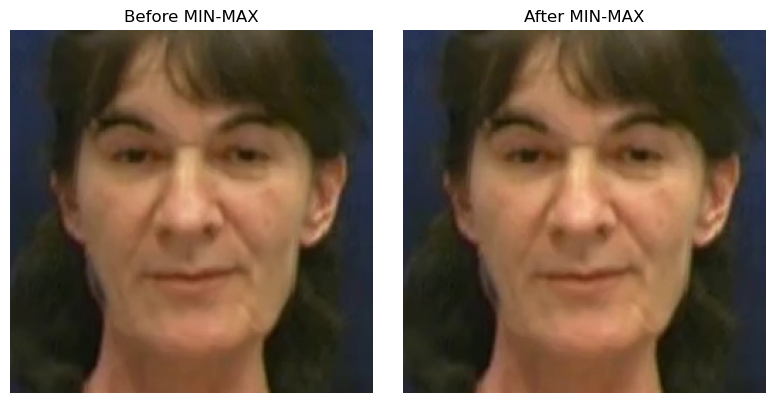

In [6]:
minmax_face = cv2.normalize(sample, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

print("before: min %d max %d   |   after: min %d max %d"
      % (sample.min(), sample.max(), minmax_face.min(), minmax_face.max()))

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(sample);       ax[0].set_title("Before MIN-MAX");  ax[0].axis("off")
ax[1].imshow(minmax_face);  ax[1].set_title("After MIN-MAX");   ax[1].axis("off")
plt.tight_layout(); plt.show()

## Summary

Starting from raw videos, the notebook ran the whole chain — **frame loop → MTCNN detection →
crop & align → normalization** — and produced three normalized representations of each face:

| Normalization | Scope | Effect |
|---|---|---|
| **Global mean/std** | whole database | removes the average face; encodes each face's deviation (doesn't look like a face) |
| **CLAHE** | per image, per channel | boosts local contrast adaptively |
| **MIN-MAX** | per image | uniform brightness/contrast range (0–255) |

Which one to use depends on the downstream task. Global normalization suits neural-net inputs; CLAHE
doubles as a data-augmentation trick; MIN-MAX gives simple, uniform contrast. All aligned faces are on
disk under `Data/faces_aligned/` for reuse.